# 🎯 Customer Churn — Ensemble v9
**Kaggle Playground Series 2026**

Changes vs v8:
- CV folds used for OOF AUC + hill climbing weights only
- Final test predictions from models retrained on FULL training data
- More training data → better test predictions
- Hill climbing weights from OOF still applied

### Structure
1. Setup & Load
2. LightGBM — CV for OOF + full retrain for test preds
3. XGBoost — CV for OOF + full retrain for test preds
4. CatBoost — CV for OOF + full retrain for test preds
5. Hill Climbing on OOF
6. OOF Analysis
7. Submission

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED    = 42
N_FOLDS = 5

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"
OUT_DIR  = "/Users/clairedebadts/kaggle/customer-churn/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv").drop(columns=['risk_score'], errors='ignore')
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()
X_test   = pd.read_csv(DATA_DIR + "X_test.csv").drop(columns=['risk_score'], errors='ignore')
test_ids = pd.read_csv(DATA_DIR + "test_ids.csv")

FEATURE_COLS = X_train.columns.tolist()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")


X_train : (594194, 40)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 40)


---
## 2. LightGBM

Step 1: 5-fold CV → OOF predictions for hill climbing
Step 2: retrain on full data → test predictions

For full retrain we use the average best iteration from CV folds
as `num_boost_round` — no early stopping needed since no validation set.

In [2]:
params_lgb = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.04,
    'num_leaves'       : 29,
    'max_depth'        : 6,
    'min_child_samples': 100,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 150,
    'verbose'          : -1,
    'random_state'     : SEED,
}

# ── Step 1: CV for OOF ────────────────────────────────────────────────────
oof_lgb      = np.zeros(len(X_train))
scores_lgb   = []
best_iters_lgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params_lgb, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(200),
        ],
    )

    oof_lgb[val_idx] = model.predict(X_val)
    best_iters_lgb.append(model.best_iteration)

    fold_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    scores_lgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_lgb = roc_auc_score(y_train, oof_lgb)
avg_iter_lgb = int(np.mean(best_iters_lgb) * 1.05)  # +5% since full data trains better
print(f"\n  LGB OOF AUC    : {auc_lgb:.5f}")
print(f"  Avg best iter  : {int(np.mean(best_iters_lgb))} → using {avg_iter_lgb} for full retrain")

# ── Step 2: Full retrain → test predictions ───────────────────────────────
print("\nRetraining LGB on full training data...")
dtrain_full = lgb.Dataset(X_train, label=y_train)
model_lgb_full = lgb.train(
    params_lgb, dtrain_full,
    num_boost_round=avg_iter_lgb,
    callbacks=[lgb.log_evaluation(200)],
)
tst_lgb = model_lgb_full.predict(X_test)
print(f"  Done. Test churn mean: {tst_lgb.mean():.4f}")


[200]	valid_0's auc: 0.914355
[400]	valid_0's auc: 0.915518
[600]	valid_0's auc: 0.915898
[800]	valid_0's auc: 0.916083
[1000]	valid_0's auc: 0.916144
[1200]	valid_0's auc: 0.916177
  Fold 1 — AUC: 0.91619 | best iter: 1230
[200]	valid_0's auc: 0.91541
[400]	valid_0's auc: 0.916406
[600]	valid_0's auc: 0.91676
[800]	valid_0's auc: 0.916993
[1000]	valid_0's auc: 0.917091
[1200]	valid_0's auc: 0.917149
[1400]	valid_0's auc: 0.917177
[1600]	valid_0's auc: 0.91721
[1800]	valid_0's auc: 0.91721
  Fold 2 — AUC: 0.91722 | best iter: 1720
[200]	valid_0's auc: 0.914797
[400]	valid_0's auc: 0.915825
[600]	valid_0's auc: 0.916239
[800]	valid_0's auc: 0.916453
[1000]	valid_0's auc: 0.916568
[1200]	valid_0's auc: 0.916638
[1400]	valid_0's auc: 0.916665
  Fold 3 — AUC: 0.91668 | best iter: 1438
[200]	valid_0's auc: 0.915812
[400]	valid_0's auc: 0.916834
[600]	valid_0's auc: 0.917234
[800]	valid_0's auc: 0.917449
[1000]	valid_0's auc: 0.917601
[1200]	valid_0's auc: 0.917679
[1400]	valid_0's auc: 0.91

---
## 3. XGBoost

Same pattern — CV for OOF, full retrain for test predictions.

In [3]:
params_xgb = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'learning_rate'    : 0.04,
    'max_depth'        : 5,
    'min_child_weight' : 50,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 150,
    'tree_method'      : 'hist',
    'random_state'     : SEED,
    'verbosity'        : 0,
}

# ── Step 1: CV for OOF ────────────────────────────────────────────────────
oof_xgb        = np.zeros(len(X_train))
scores_xgb     = []
best_iters_xgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval   = xgb.DMatrix(X_val, label=y_val)

    model = xgb.train(
        params_xgb, dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=150,
        verbose_eval=200,
    )

    oof_xgb[val_idx] = model.predict(dval)
    best_iters_xgb.append(model.best_iteration)

    fold_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    scores_xgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_xgb = roc_auc_score(y_train, oof_xgb)
avg_iter_xgb = int(np.mean(best_iters_xgb) * 1.05)
print(f"\n  XGB OOF AUC    : {auc_xgb:.5f}")
print(f"  vs LGB         : {auc_xgb - auc_lgb:+.5f}")
print(f"  Avg best iter  : {int(np.mean(best_iters_xgb))} → using {avg_iter_xgb} for full retrain")

# ── Step 2: Full retrain → test predictions ───────────────────────────────
print("\nRetraining XGB on full training data...")
dtrain_full = xgb.DMatrix(X_train, label=y_train)
model_xgb_full = xgb.train(
    params_xgb, dtrain_full,
    num_boost_round=avg_iter_xgb,
    verbose_eval=200,
)
tst_xgb = model_xgb_full.predict(xgb.DMatrix(X_test))
print(f"  Done. Test churn mean: {tst_xgb.mean():.4f}")


[0]	val-auc:0.89603
[200]	val-auc:0.91409
[400]	val-auc:0.91530
[600]	val-auc:0.91577
[800]	val-auc:0.91600
[1000]	val-auc:0.91617
[1200]	val-auc:0.91626
[1400]	val-auc:0.91629
[1600]	val-auc:0.91633
[1800]	val-auc:0.91637
[1999]	val-auc:0.91638
  Fold 1 — AUC: 0.91638 | best iter: 1997
[0]	val-auc:0.89684
[200]	val-auc:0.91508
[400]	val-auc:0.91622
[600]	val-auc:0.91667
[800]	val-auc:0.91693
[1000]	val-auc:0.91710
[1200]	val-auc:0.91719
[1400]	val-auc:0.91725
[1600]	val-auc:0.91730
[1800]	val-auc:0.91733
[1999]	val-auc:0.91735
  Fold 2 — AUC: 0.91735 | best iter: 1993
[0]	val-auc:0.89666
[200]	val-auc:0.91453
[400]	val-auc:0.91570
[600]	val-auc:0.91614
[800]	val-auc:0.91639
[1000]	val-auc:0.91653
[1200]	val-auc:0.91663
[1400]	val-auc:0.91668
[1600]	val-auc:0.91672
[1800]	val-auc:0.91674
[1999]	val-auc:0.91675
  Fold 3 — AUC: 0.91675 | best iter: 1994
[0]	val-auc:0.89768
[200]	val-auc:0.91558
[400]	val-auc:0.91671
[600]	val-auc:0.91720
[800]	val-auc:0.91743
[1000]	val-auc:0.91757
[1200

---
## 4. CatBoost

Same pattern — CV for OOF, full retrain for test predictions.

In [4]:
# ── Step 1: CV for OOF ────────────────────────────────────────────────────
oof_cat        = np.zeros(len(X_train))
scores_cat     = []
best_iters_cat = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = CatBoostClassifier(
        iterations            = 2000,
        learning_rate         = 0.04,
        depth                 = 6,
        l2_leaf_reg           = 150,
        min_data_in_leaf      = 50,
        eval_metric           = 'AUC',
        early_stopping_rounds = 150,
        random_seed           = SEED,
        verbose               = 200,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    oof_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    best_iters_cat.append(model.best_iteration_)

    fold_auc = roc_auc_score(y_val, oof_cat[val_idx])
    scores_cat.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration_}")

auc_cat = roc_auc_score(y_train, oof_cat)
avg_iter_cat = int(np.mean(best_iters_cat) * 1.05)
print(f"\n  CAT OOF AUC    : {auc_cat:.5f}")
print(f"  vs LGB         : {auc_cat - auc_lgb:+.5f}")
print(f"  vs XGB         : {auc_cat - auc_xgb:+.5f}")
print(f"  Avg best iter  : {int(np.mean(best_iters_cat))} → using {avg_iter_cat} for full retrain")

print("\nOOF correlation:")
oof_df = pd.DataFrame({'LGB': oof_lgb, 'XGB': oof_xgb, 'CAT': oof_cat})
print(oof_df.corr().round(4).to_string())

# ── Step 2: Full retrain → test predictions ───────────────────────────────
print("\nRetraining CatBoost on full training data...")
model_cat_full = CatBoostClassifier(
    iterations       = avg_iter_cat,
    learning_rate    = 0.04,
    depth            = 6,
    l2_leaf_reg      = 150,
    min_data_in_leaf = 50,
    eval_metric      = 'AUC',
    random_seed      = SEED,
    verbose          = 200,
)
model_cat_full.fit(X_train, y_train)
tst_cat = model_cat_full.predict_proba(X_test)[:, 1]
print(f"  Done. Test churn mean: {tst_cat.mean():.4f}")


0:	test: 0.8974997	best: 0.8974997 (0)	total: 188ms	remaining: 6m 16s
200:	test: 0.9136339	best: 0.9136339 (200)	total: 28.5s	remaining: 4m 14s
400:	test: 0.9146507	best: 0.9146507 (400)	total: 1m 5s	remaining: 4m 20s
600:	test: 0.9152402	best: 0.9152402 (600)	total: 1m 39s	remaining: 3m 50s
800:	test: 0.9155574	best: 0.9155574 (800)	total: 2m 11s	remaining: 3m 17s
1000:	test: 0.9157853	best: 0.9157853 (1000)	total: 3m 15s	remaining: 3m 14s
1200:	test: 0.9159224	best: 0.9159230 (1197)	total: 4m 21s	remaining: 2m 54s
1400:	test: 0.9160200	best: 0.9160200 (1400)	total: 5m 17s	remaining: 2m 15s
1600:	test: 0.9160959	best: 0.9160990 (1589)	total: 6m 19s	remaining: 1m 34s
1800:	test: 0.9161336	best: 0.9161337 (1798)	total: 7m 36s	remaining: 50.5s
1999:	test: 0.9161697	best: 0.9161712 (1996)	total: 9m 38s	remaining: 0us

bestTest = 0.9161711815
bestIteration = 1996

Shrink model to first 1997 iterations.
  Fold 1 — AUC: 0.91617 | best iter: 1996
0:	test: 0.8988036	best: 0.8988036 (0)	total: 

---
## 5. Hill Climbing

In [5]:
def hill_climbing(oofs, y, n_iter=3000, step=0.01):
    n_models = len(oofs)
    weights  = np.array([1.0 / n_models] * n_models)
    best_auc = roc_auc_score(y, sum(w * o for w, o in zip(weights, oofs)))

    print(f"Starting AUC (equal weights): {best_auc:.5f}")
    print(f"  Initial weights: {[round(w,3) for w in weights]}\n")

    improved  = True
    iteration = 0
    while improved and iteration < n_iter:
        improved = False
        iteration += 1
        for i in range(n_models):
            new_w = weights.copy()
            new_w[i] += step
            new_w /= new_w.sum()
            auc = roc_auc_score(y, sum(w * o for w, o in zip(new_w, oofs)))
            if auc > best_auc:
                best_auc = auc
                weights  = new_w
                improved = True

    print(f"Converged after {iteration} iterations")
    print(f"Best OOF AUC : {best_auc:.5f}")
    print(f"Best weights :")
    for name, w in zip(['LGB', 'XGB', 'CAT'], weights):
        print(f"  {name} : {w:.4f} ({w*100:.1f}%)")
    return weights, best_auc

oofs = [oof_lgb, oof_xgb, oof_cat]
tsts = [tst_lgb, tst_xgb, tst_cat]

best_weights, auc_blend = hill_climbing(oofs, y_train)

# Apply OOF weights to full-retrain test predictions
tst_blend = sum(w * t for w, t in zip(best_weights, tsts))

print(f"\n{'='*45}")
print(f"  LGB alone   : {auc_lgb:.5f}")
print(f"  XGB alone   : {auc_xgb:.5f}")
print(f"  CAT alone   : {auc_cat:.5f}")
print(f"  Equal blend : {roc_auc_score(y_train, sum(o/3 for o in oofs)):.5f}")
print(f"  Hill climb  : {auc_blend:.5f}  ← best")
print(f"  vs v8 blend : {auc_blend - 0.91669:+.5f}")
print(f"{'='*45}")
print(f"\nTest blend mean: {tst_blend.mean():.4f}  (should be ~0.225)")


Starting AUC (equal weights): 0.91677
  Initial weights: [0.333, 0.333, 0.333]

Converged after 25 iterations
Best OOF AUC : 0.91678
Best weights :
  LGB : 0.2377 (23.8%)
  XGB : 0.4409 (44.1%)
  CAT : 0.3214 (32.1%)

  LGB alone   : 0.91656
  XGB alone   : 0.91666
  CAT alone   : 0.91649
  Equal blend : 0.91677
  Hill climb  : 0.91678  ← best
  vs v8 blend : +0.00009

Test blend mean: 0.2182  (should be ~0.225)


---
## 6. OOF Analysis

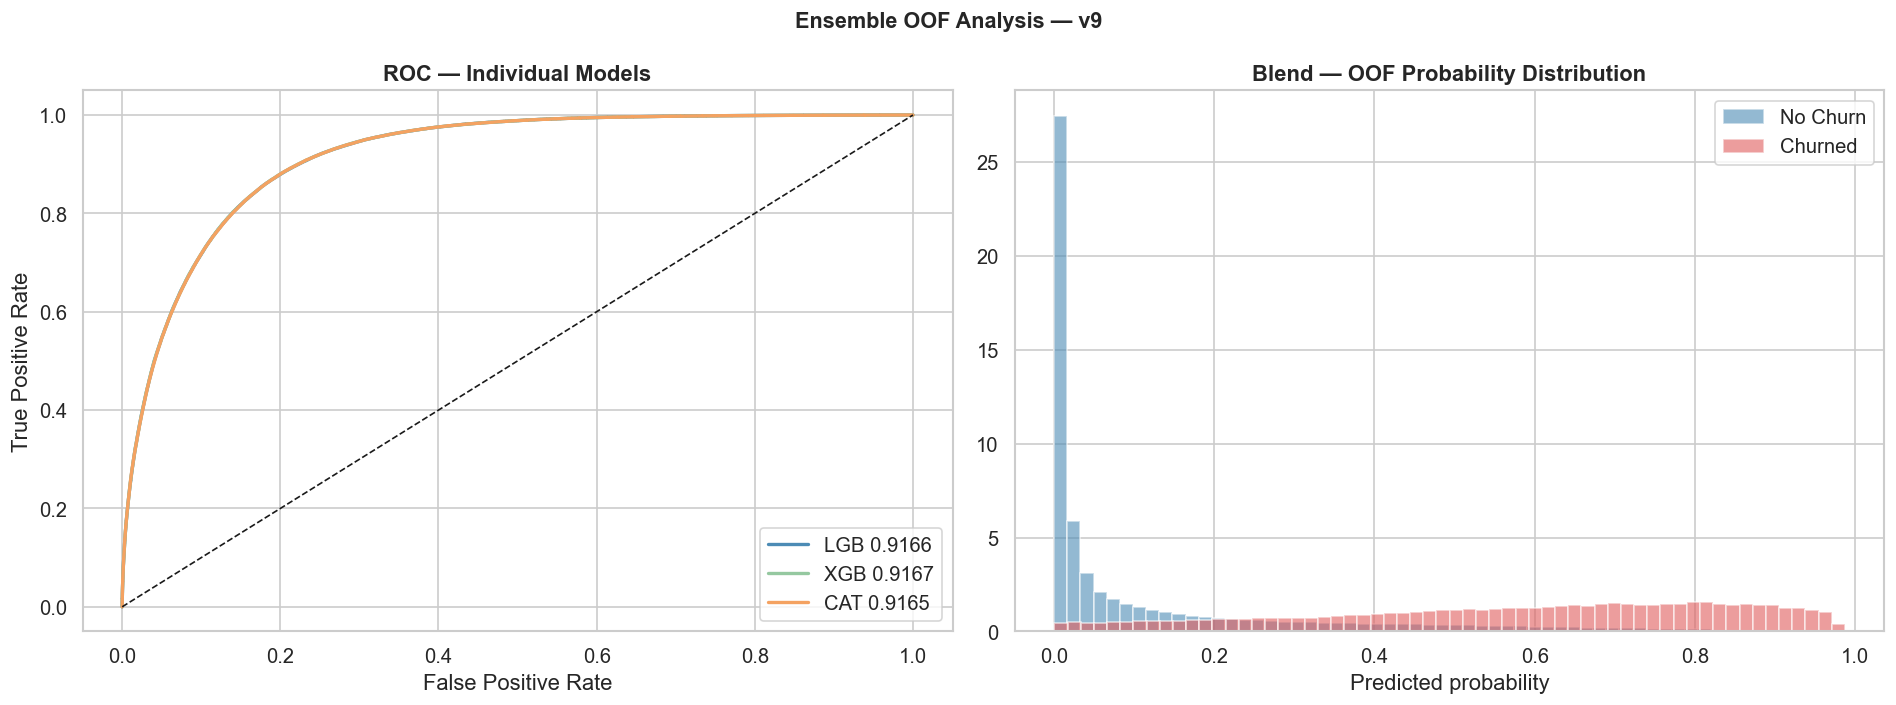

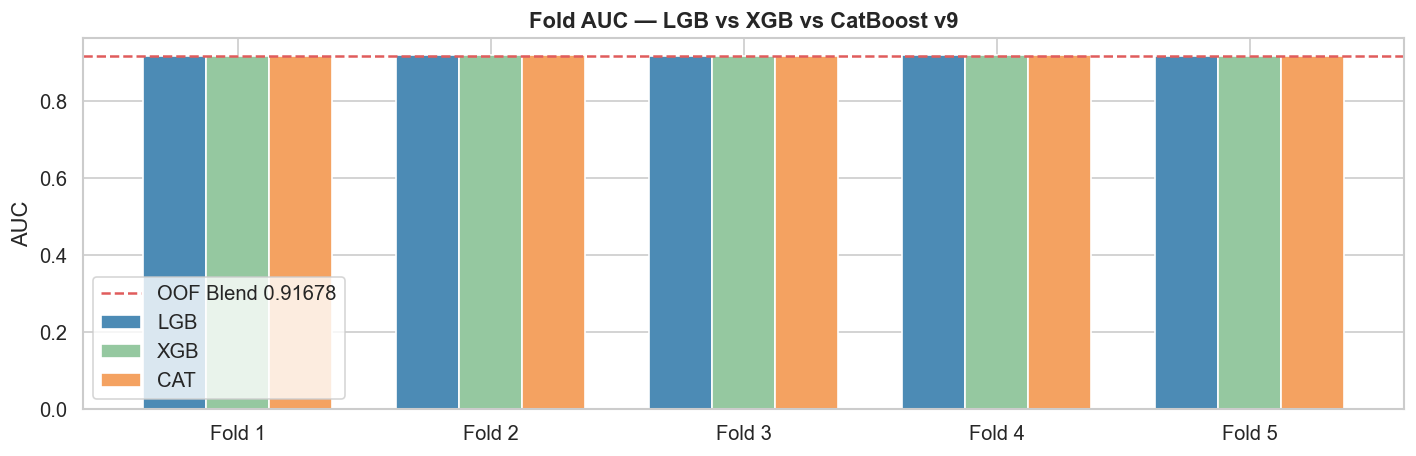

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, oof, auc, color in [
    ('LGB', oof_lgb, auc_lgb, '#4C8BB5'),
    ('XGB', oof_xgb, auc_xgb, '#95C8A0'),
    ('CAT', oof_cat, auc_cat, '#F4A261'),
]:
    fpr, tpr, _ = roc_curve(y_train, oof)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].set_title('ROC — Individual Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

oof_final = sum(w * o for w, o in zip(best_weights, oofs))
axes[1].hist(oof_final[y_train==0], bins=60, alpha=0.6,
             color='#4C8BB5', label='No Churn', density=True)
axes[1].hist(oof_final[y_train==1], bins=60, alpha=0.6,
             color='#E05C5C', label='Churned', density=True)
axes[1].set_title('Blend — OOF Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

plt.suptitle('Ensemble OOF Analysis — v9', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
x  = np.arange(N_FOLDS)
bw = 0.25
ax.bar(x - bw, scores_lgb, width=bw, label='LGB', color='#4C8BB5', edgecolor='white')
ax.bar(x,      scores_xgb, width=bw, label='XGB', color='#95C8A0', edgecolor='white')
ax.bar(x + bw, scores_cat, width=bw, label='CAT', color='#F4A261', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, N_FOLDS+1)])
ax.axhline(auc_blend, color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f'OOF Blend {auc_blend:.5f}')
ax.set_title('Fold AUC — LGB vs XGB vs CatBoost v9', fontweight='bold')
ax.set_ylabel('AUC')
ax.legend()
plt.tight_layout()
plt.show()


---
## 7. Submission

Sanity checks: ✅
Rows       : 254,655
Churn mean : 0.2182  (train: 0.2252)

Final summary:
  LGB alone  : OOF 0.91656
  XGB alone  : OOF 0.91666
  CAT alone  : OOF 0.91649
  OOF Blend  : 0.91678
  Weights    : LGB=0.24 XGB=0.44 CAT=0.32

  v8 LB      : 0.91420
  Target     : 0.91726 (best public notebook)


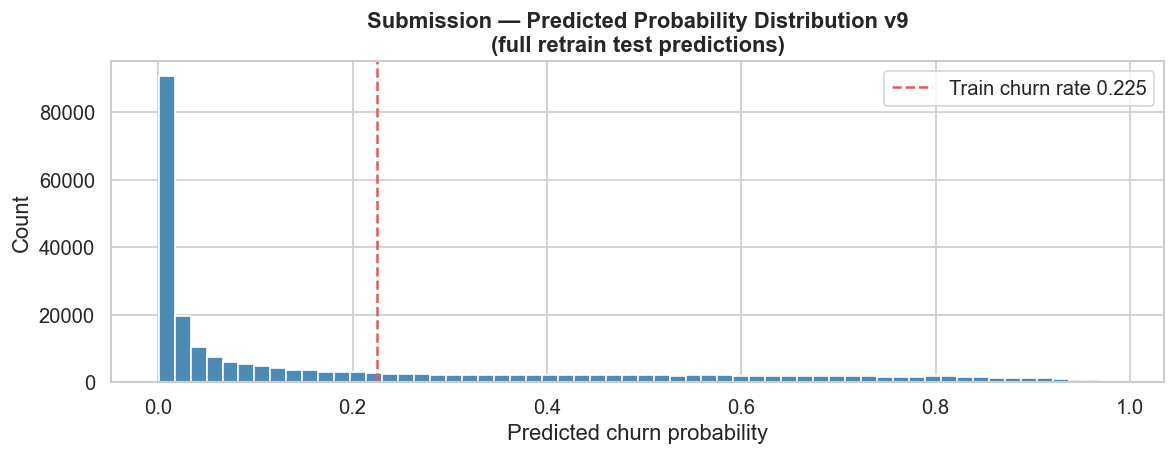


✅ Saved: /Users/clairedebadts/kaggle/customer-churn/submission_v9.csv


In [7]:
import os

submission = pd.DataFrame({
    'id'   : test_ids['id'],
    'Churn': tst_blend
})

assert submission['id'].nunique() == len(submission)
assert submission['Churn'].between(0, 1).all()
assert submission.isnull().sum().sum() == 0
print("Sanity checks: ✅")
print(f"Rows       : {len(submission):,}")
print(f"Churn mean : {submission['Churn'].mean():.4f}  (train: {y_train.mean():.4f})")
print(f"\nFinal summary:")
print(f"  LGB alone  : OOF {auc_lgb:.5f}")
print(f"  XGB alone  : OOF {auc_xgb:.5f}")
print(f"  CAT alone  : OOF {auc_cat:.5f}")
print(f"  OOF Blend  : {auc_blend:.5f}")
print(f"  Weights    : LGB={best_weights[0]:.2f} XGB={best_weights[1]:.2f} CAT={best_weights[2]:.2f}")
print(f"\n  v8 LB      : 0.91420")
print(f"  Target     : 0.91726 (best public notebook)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(submission['Churn'], bins=60, color='#4C8BB5', edgecolor='white')
ax.axvline(y_train.mean(), color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f'Train churn rate {y_train.mean():.3f}')
ax.set_title('Submission — Predicted Probability Distribution v9\n(full retrain test predictions)',
             fontweight='bold')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(OUT_DIR + "submission_v9.csv", index=False)
print(f"\n✅ Saved: {OUT_DIR}submission_v9.csv")
